# POC 02 (v3) — training, window reconstruction and aligned prototypes

**v3 fixes the v2 run.** `data.build_windows` used to cache the resolved `fl` together with
the windows. Every later spec with the same windows therefore inherited the first spec's
`training` / `model` blocks, so all "long" cells trained 5 × 1. `fl` is now rebuilt on every
call, and `run_cell` asserts that it matches the spec. §1b audits the store and purges runs
saved under the bug. **Restart the kernel** before running: the cache format changed.

This notebook is self-contained: world → sensors → **training grid** → sanity → window
reconstruction → aligned prototypes → invariance. Any cell missing from the store trains
here; cells already in the store are cache reads.

The previous version found that single windows decode flat (`window_amp` ≈ 0.03). Its §8
traced this to three things:
* **Undertraining:** about 35 Adam steps per client.
* **A dominant prototype term:** 69% of the loss.
* **A position signal that was not learned:** η² lift was identical at round −1.

This version tests the fixes.

| module | what it adds |
|---|---|
| `specs` | `training.proto_weight` (upstream knob) and `LossTerms` (lab-side objective) |
| `train` | `_local_update_lab`, `untrained_model` (round −1), `equivalence_check` |
| `aligned` | controls on every window, `invariance`, `sanity`, `plot_losses` |
| `winrec` | per-window scores, overlap-add timeline, window browser |

**Needs** the patched `fl_training/federated.py` for the `up pw0` cell. Without it, that cell
is refused with a message and the lab cells still run.

## 0. Setup

In [1]:
import sys, pathlib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from fedwater_lab.worlds import load_world, list_worlds, pick_world
from fedwater_lab.store import Store
from fedwater_lab.specs import POC, Geometry, LossTerms
from fedwater_lab.runner import run_cell
from fedwater_lab import data as D, recon as RC, train as T
from fedwater_lab import aligned as AL, winrec as WR

EXPERIMENTS = REPO / "data" / "09_experiments"
pd.set_option("display.width", 220, "display.max_columns", 40)

## 1. World and sensors

The selection is the same as POC_01 / the first POC_02 run, so the `base` cell below is a
cache read of that run.

In [2]:
FILTERS = dict(sim_hash="ece8f4ad92e5", placement_source="dynamic")
world = load_world(pick_world(EXPERIMENTS, **FILTERS))
store = Store(LAB_DIR / "lab_sandbox")
print(world.summary().to_string())

SELECTION = dict(kinds=("flow",), classes=("pure", "mixed"), include=(), exclude=())
BASE = POC.with_(**SELECTION)

kept = D.sensor_table(world, BASE)
why = ["district", "slot", "slot_class", "sensor", "tier", "purity", "second", "w_second"]
display(kept[[c for c in why if c in kept.columns]].round(3))

sim_hash                                 ece8f4ad92e5
tag                 District_A__LR_LR_LR_LR__baseline
network                                          ky72
districting                                  spectral
partition_id                                 29fddafe
placement_source                              dynamic
n_months                                           65
resolution_h                                        1
steps_day                                          24
clients                                             4
n_sensors                                          32
n_pure                                             16
n_mixed                                            16
drift_district                             District_A
warmup_months                                      12
first_switch                                       12
last_switch                                        63
ramp_days                                         7.0
init_months                 

,district,slot,slot_class,sensor,tier,purity,second,w_second
0,District_A,q_mixed_0,mixed,q_P-558,foreign,0.000,District_B,0.725
1,District_A,q_mixed_1,mixed,q_P-10,transition,0.272,District_D,0.728
2,District_A,q_pure_0,pure,q_P-42,core,1.000,NaN,0.000
3,District_A,q_pure_1,pure,q_P-556,core,1.000,NaN,0.000
4,District_B,q_mixed_0,mixed,q_P-605,foreign,0.000,District_A,0.656
5,District_B,q_mixed_1,mixed,q_P-588,transition,0.477,District_C,0.263
6,District_B,q_pure_0,pure,q_P-30,core,1.000,NaN,0.000
7,District_B,q_pure_1,pure,q_P-285,core,1.000,NaN,0.000
8,District_C,q_mixed_0,mixed,q_P-518,transition,0.437,District_B,0.290
9,District_C,q_mixed_1,mixed,q_P-521,transition,0.254,District_B,0.378


### 1b. Store audit

For every saved run of this world, the audit compares `spec.json` (what the run key says)
with `fl.json` (what actually trained). Rows with `ok = False` were saved under the caching
bug and **must be purged** before §2, otherwise they are served as cache hits. Set
`PURGE = True` to delete exactly those rows.

In [3]:
AUDIT = store.audit(world.sim_hash)
display(AUDIT[["run_key", "label", "rounds_spec", "rounds_fl", "epochs_spec", "epochs_fl",
               "ok", "mismatch"]])

PURGE = False
bad = AUDIT.loc[~AUDIT["ok"], "run_key"].tolist()
if PURGE and bad:
    print("purged:", store.purge(world.sim_hash, bad))
    display(store.audit(world.sim_hash)[["run_key", "label", "ok"]])
elif bad:
    print(f"{len(bad)} run(s) disagree with their spec -- set PURGE = True to remove them")

,run_key,label,rounds_spec,rounds_fl,epochs_spec,epochs_fl,ok,mismatch
0,028ca9bf44b3,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,30,5,5,1,False,training.rounds: spec=30 fl=5; training.local_...
1,1eba1bd89cd4,fmp__none__minmax_ref__a2w84s12__u30r5s0,5,5,1,1,True,
2,24403632d296,fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0,30,5,5,1,False,training.rounds: spec=30 fl=5; training.local_...
3,3675c1f38427,fmp__none__minmax_ref__a3w84s12__u30r5s0,5,5,1,1,True,
4,36dfdcd31d13,fmp__none__minmax_ref__a1w24s12__u30r5s0,5,5,1,1,True,
5,3a1e4ba62977,fmp__none__minmax_ref__a2w168s24__u30r5s0,5,5,1,1,True,
6,70e0fc12832b,fmp__none__minmax_ref__a3w84s12__u30r15s0,15,15,1,1,True,
7,766ed3159174,fmp__none__minmax_ref__a2w128s24__u30r5s0,5,5,1,1,True,
8,79139ce2449a,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lv1,30,5,5,1,False,training.rounds: spec=30 fl=5; training.local_...
9,91e9ca3d8e16,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,30,5,5,1,False,training.rounds: spec=30 fl=5; training.local_...


6 run(s) disagree with their spec -- set PURGE = True to remove them


## 2. Training grid

**Two ways to change the objective:**

* **Upstream:** `training.proto_weight` $=\lambda$ gives
  `loss = aer_loss + λ · proto_loss`, read by the patched `FPLTrainer`. Leaving it unset keeps
  the protocol unchanged, and the run key is unchanged too.
* **Lab:** `loss_terms=LossTerms(...)` makes the lab re-implement `_local_update`:

$$\mathcal{L} = \mathcal{L}_{AER} + \lambda_p\,\mathcal{L}_{proto}\,[r \ge r_0]
+ \lambda_d\,\mathrm{MSE}(\partial_t \hat x, \partial_t x)
+ \lambda_s\,\mathrm{MSE}(|\mathcal{F}\hat y|, |\mathcal{F} y|)
+ \lambda_v\,\tfrac{1}{d}\textstyle\sum_j \mathrm{relu}(\gamma - \sigma_{batch}(z_j))$$

where:
* $\partial_t$ is the first difference over the full window.
* $\mathcal{F}$ is the orthonormal FFT over steps $1..W-2$, applied after removing each
  window's mean.
* $\sigma_{batch}$ is the per-dimension std of the latent over the batch.

A flat reconstruction pays the target's full derivative energy ($\lambda_d$) and spectral
energy ($\lambda_s$), which is exactly what the flat-line minimum hides. The variance hinge
($\lambda_v$, VICReg) keeps latent dimensions spread against the prototype pull.
`LossTerms()` reproduces upstream bit for bit, and the check below asserts it on this world's
windows.

`long` is 30 rounds × 5 local epochs, about 1,050 Adam steps per client against about 35 for
`base`. Fill `TRAIN` with the cells to (re)train. Cells already in the store are skipped.

In [4]:
LONG = {"training.rounds": 30, "training.local_epochs": 5}
CELLS = {
    "base":             BASE,
    "long":             BASE.with_(**LONG),
    "long·up pw0":      BASE.with_(**LONG, **{"training.proto_weight": 0.0}),
    "long·lab pw0":     BASE.with_(**LONG, loss_terms=LossTerms(proto_weight=0.0)),
    "long·lab pw.1+d":  BASE.with_(**LONG, loss_terms=LossTerms(proto_weight=0.1, diff=1.0)),
    "long·lab pw.1+s":  BASE.with_(**LONG, loss_terms=LossTerms(proto_weight=0.1, spec=1.0)),
    "long·lab v":       BASE.with_(**LONG, loss_terms=LossTerms(var=1.0, var_gamma=0.1)),
}
TRAIN = list(CELLS)

display(pd.DataFrame([{"cell": k, "label": s.label(),
                       "in store": store.exists(world, s)} for k, s in CELLS.items()]))

,cell,label,in store
0,base,fmp__none__minmax_ref__a3w84s12__u30r5s0,True
1,long,fmp__none__minmax_ref__a3w84s12__u30r30e5s0,True
2,long·up pw0,fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0,True
3,long·lab pw0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,True
4,long·lab pw.1+d,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,True
5,long·lab pw.1+s,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,True
6,long·lab v,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lv1,True


### 2a. Lab loop equals upstream

This trains 2 short rounds on CPU with this world's windows and compares final weights and
every local prototype:
* upstream against `LossTerms()`;
* upstream `proto_weight=0` against `LossTerms(proto_weight=0)`.

Both must be `identical`. On GPU the two paths can still differ in the last digits (cuDNN), so
their long runs are compared on the metrics, not bit for bit.

In [5]:
fw0, _, fl0 = D.build_windows(world, BASE, cache=D.CACHE)
EQ = T.equivalence_check(fw0, fl0, seed=0, rounds=2)
display(EQ)
assert EQ["identical"].iloc[0], "lab loop diverges from upstream"

,pair,max_abs_weight_diff,max_abs_proto_diff,identical
0,upstream vs LossTerms(),0.0,0.0,True
1,upstream pw=0 vs LossTerms(proto_weight=0),0.0,0.0,True


In [7]:
RUNS = {}
for name in TRAIN:
    spec = CELLS[name]
    t0 = time.time()
    try:
        res = run_cell(world, spec, store=store, verbose=True)
    except RuntimeError as exc:           # e.g. upstream proto_weight without the patch
        print(f"{name:<18} REFUSED: {exc}")
        continue
    bad = T.fl_mismatches(spec, res["fl"])
    if bad:
        raise AssertionError(f"{name}: stored run trained with {bad} -- purge it (§1b)")
    RUNS[name] = res["run_key"]
    print(f"{name:<18} {res['run_key']}  cache_hit={res['cache_hit']}  "
          f"{time.time() - t0:.0f}s")

  round   0  loss 0.39559  online 4
  round   1  loss 1.24740  online 4
  round   2  loss 1.22392  online 4
  round   3  loss 1.19467  online 4
  round   4  loss 1.18221  online 4
base               3675c1f38427  cache_hit=False  22s
  round   0  loss 0.34318  online 4
  round   1  loss 1.14794  online 4
  round   2  loss 1.10489  online 4
  round   3  loss 1.08152  online 4
  round   4  loss 1.07880  online 4
  round   5  loss 1.07634  online 4
  round   6  loss 1.06613  online 4
  round   7  loss 1.05415  online 4
  round   8  loss 1.04815  online 4
  round   9  loss 1.04715  online 4
  round  10  loss 1.04431  online 4
  round  11  loss 1.02713  online 4
  round  12  loss 1.04233  online 4
  round  13  loss 1.02748  online 4
  round  14  loss 1.01548  online 4
  round  15  loss 0.99992  online 4
  round  16  loss 1.00590  online 4
  round  17  loss 0.99780  online 4
  round  18  loss 0.98718  online 4
  round  19  loss 0.99143  online 4
  round  20  loss 0.98912  online 4
  round  2

## 3. Sanity, per cell

Each cell is decoded and checked against the **untrained control**. That is the round −1
model, rebuilt from the seed and asserted equal to the saved round −1 snapshot, and it is
applied to every window.

| column | meaning |
|---|---|
| `steps/client` | rounds × local epochs × batches |
| `d_mse_last` | relative change of `loss_mse` at the last round; < 0 means still learning |
| `aux_share` | $1 -$ `loss_mse` / `loss`, last round: the weighted share of the objective that is not reconstruction |
| `final_over_wmean` | final AER loss / best flat line (each window's own mean); < 1 means shape is captured |
| `window_amp`, `window_r` | median $\sigma_t(\hat x)/\sigma_t(x)$ and $\mathrm{corr}_t(\hat x, x)$ per window |
| `level_r` | $\mathrm{corr}_w$ of window means, decoded vs true |
| `eta_lift_final` / `_ctrl` | §4 η² lift (time-of-day key), trained vs untrained, all windows |
| `rel_block_first/last` | within-month latent spread / latent norm, first and last snapshot |
| `ctrl_window_amp` | the same amplitude score for the untrained model |

This takes about a minute per cell (decoding, permutations, control). `sanity` raises if a run's
saved `fl` or its log length disagrees with the spec.

,base,long,long·up pw0,long·lab pw0,long·lab pw.1+d,long·lab pw.1+s,long·lab v
label,fmp__none__minmax_ref__a3w84s12__u30r5s0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0,fmp__none__minmax_ref__a3w84s12__u30r30e5pw0s0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__L...,fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lv1
run_key,3675c1f38427,ebf14537cde1,24403632d296,91e9ca3d8e16,028ca9bf44b3,949895d5bea0,79139ce2449a
steps/client,35,1050,1050,1050,1050,1050,1050
loss_mse_last,0.365842,0.237278,0.221434,0.221434,0.173043,0.185641,0.222313
d_mse_last,-0.020736,0.0639,0.082102,0.082102,-0.005078,-0.056951,-0.052085
aux_share,0.690543,0.759911,0.0,0.0,0.613284,0.457517,0.766317
final_over_wmean,1.314404,1.016988,0.811864,0.811864,1.001411,0.954179,0.975783
final_over_const,1.130924,0.910063,0.719067,0.719067,0.87997,0.860403,0.874005
window_amp,0.028651,0.094559,0.086598,0.086598,0.181824,0.627677,0.111446
window_r,0.00011,0.061846,0.13949,0.13949,0.267309,0.308122,0.05064


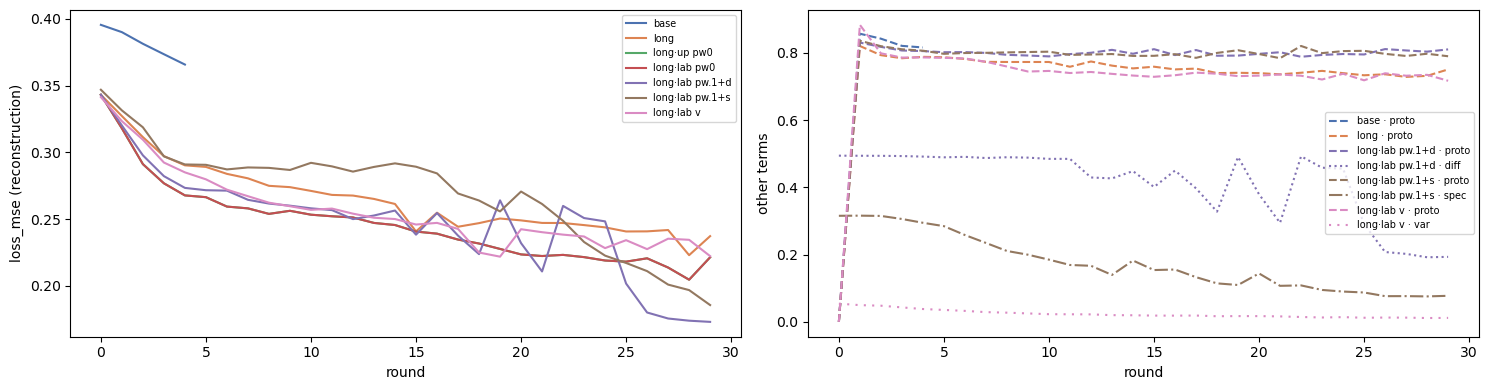

In [8]:
ALIGN24 = AL.Alignment(period_h=24, bin_h=None, block=1)
OUTS, SAN = {}, {}
for name in RUNS:
    OUTS[name] = AL.analyse(world, CELLS[name], ALIGN24, store=store, server=False, n_perm=99)
    SAN[name] = AL.sanity(world, OUTS[name], n_perm=99)
    assert OUTS[name]["checks"]["passed"].all(), OUTS[name]["checks"]
    assert SAN[name]["control_check"]["passed"].all(), SAN[name]["control_check"]

SANITY = pd.DataFrame({k: v["row"] for k, v in SAN.items()})
display(SANITY)

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
AL.plot_losses(ax, {k: OUTS[k]["res"]["training_log"] for k in OUTS})
fig.tight_layout()
plt.show()

## 4. Focus cell

Everything below reads one cell. The objects are:
* `run`: the trained model on every window, keyed by time of day.
* `ctrl`: the same for the untrained model.
* `channels`: slot, class and mixture label of each channel.

In [16]:
FOCUS = "long·lab pw.1+d"                     # any key of OUTS
out, san = OUTS[FOCUS], SAN[FOCUS]
run, ctrl, fw, model = out["run"], san["control"], out["fw"], out["model"]
spec_f = CELLS[FOCUS]
channels = RC.channel_table(world, fw)
print(spec_f.label())
display(channels)

fmp__none__minmax_ref__a3w84s12__u30r30e5s0__Lp0.1-d1


,client,channel,slot,sensor,kind,slot_class,w_District_A,w_District_B,w_District_C,w_District_D
0,District_A,0,q_mixed_0,q_P-558,flow,mixed,0.000000,0.724639,0.275361,0.000000
1,District_A,1,q_mixed_1,q_P-10,flow,mixed,0.272429,0.000000,0.000000,0.727571
2,District_A,2,q_pure_0,q_P-42,flow,pure,1.000000,0.000000,0.000000,0.000000
3,District_A,3,q_pure_1,q_P-556,flow,pure,1.000000,0.000000,0.000000,0.000000
4,District_B,0,q_mixed_0,q_P-605,flow,mixed,0.656441,0.000000,0.343559,0.000000
5,District_B,1,q_mixed_1,q_P-588,flow,mixed,0.259996,0.476966,0.263038,0.000000
6,District_B,2,q_pure_0,q_P-30,flow,pure,0.000000,1.000000,0.000000,0.000000
7,District_B,3,q_pure_1,q_P-285,flow,pure,0.000000,1.000000,0.000000,0.000000
8,District_C,0,q_mixed_0,q_P-518,flow,mixed,0.272517,0.290256,0.437227,0.000000
9,District_C,1,q_mixed_1,q_P-521,flow,mixed,0.368882,0.377574,0.253544,0.000000


## 5. Window reconstruction

Scores are computed per window and per channel. The AER encodes all channels of a window
jointly, so a channel's reconstruction is a slice of one output.

* `rmse` $=\sqrt{\mathrm{mean}_t(\hat x - x)^2}$
* `r` $=\mathrm{corr}_t(\hat x, x)$
* `amp` $=\sigma_t\hat x / \sigma_t x$
* `lvl` $=\overline{\hat x} - \bar x$

The tables are medians per phase × slot class, for the trained model and the untrained one.
The position profile gives, for each position $t$ inside the window, $\mathrm{corr}_w(\hat
x_w[t], x_w[t])$ over windows. A decoder that reproduces the first steps and then settles to a
constant shows it falling to 0.
The grids show the median `r` over month × start class (weekday·hour, with weekday = day mod 7
from step 0, as in the demand model). A row that stays pale across months is a calendar class
the model does not reconstruct.

In the browser, the top panel is one window with its reconstruction (and the untrained one if
selected). The bottom panel is the **overlap-add** timeline: each step is the mean of every
covering window's reconstruction at that step, drawn against the true series, with
weekday 5–6 shaded.

phase slot_class   rmse      r    amp    lvl     n
trained   0        init      mixed  0.579  0.203  0.167 -0.035   568
          1        init       pure  0.567  0.326  0.153 -0.019   568
          2  transition      mixed  0.528  0.193  0.192 -0.029  2496
          3  transition       pure  0.560  0.284  0.174  0.049  2496
          4       final      mixed  0.472  0.131  0.208 -0.056    32
          5       final       pure  0.563  0.280  0.181  0.054    32
untrained 0        init      mixed  0.605  0.047  0.001 -0.087   568
          1        init       pure  0.600 -0.013  0.003  0.004   568
          2  transition      mixed  0.598  0.038  0.001 -0.013  2496
          3  transition       pure  0.605 -0.012  0.002  0.133  2496
          4       final      mixed  0.554  0.033  0.001  0.008    32
          5       final       pure  0.611 -0.028  0.002  0.135    32

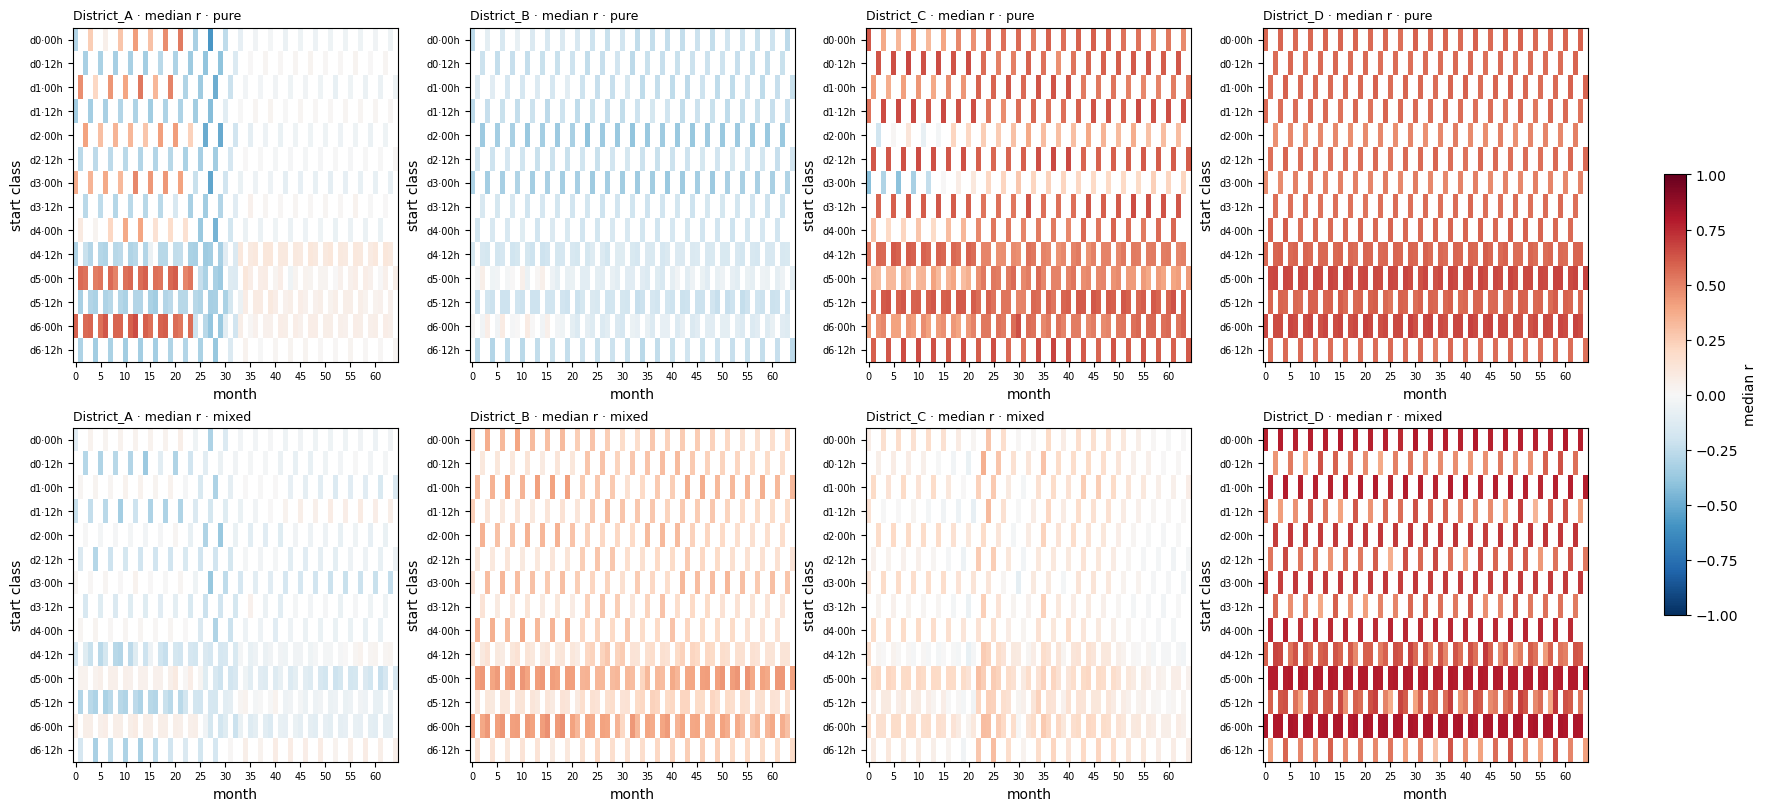

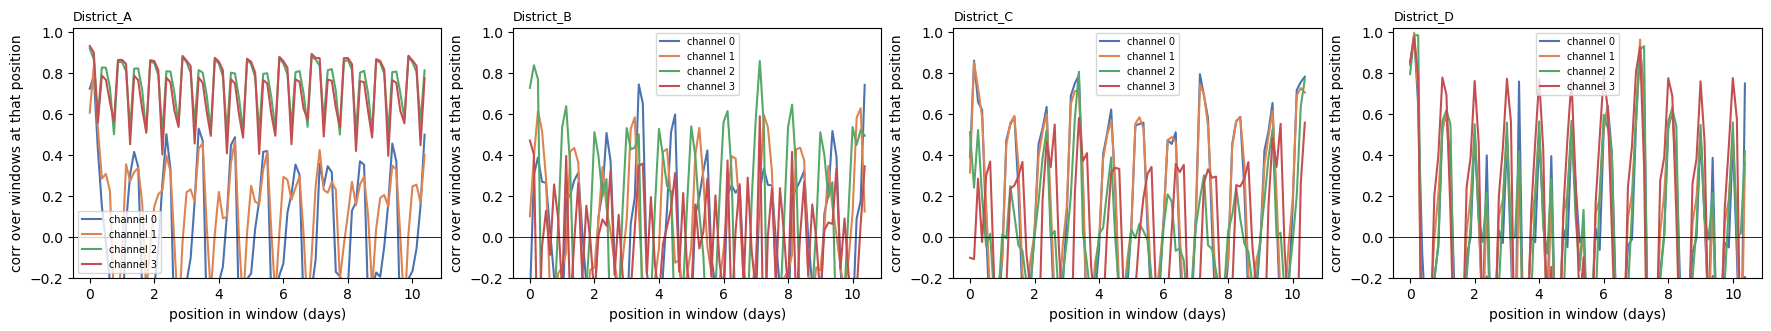

In [17]:
WS = WR.window_scores(run, fw, channels)
WS_C = WR.window_scores(ctrl, fw, channels)
display(pd.concat({"trained": WR.score_summary(WS), "untrained": WR.score_summary(WS_C)})
          .round(3))

clients = world.client_names
fig, axes = plt.subplots(2, len(clients), figsize=(4.4 * len(clients), 8), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    for i, cls in enumerate(("pure", "mixed")):
        im = WR.plot_score_grid(axes[i, j], WS, c, "r", cls)
fig.colorbar(im, ax=axes, shrink=0.6, label="median r")
plt.show()

# position profile: corr over windows at each position inside the window
fig, axes = plt.subplots(1, len(clients), figsize=(4.4 * len(clients), 3.2), squeeze=False,
                         layout="constrained")
for j, c in enumerate(clients):
    WR.plot_step_profile(axes[0, j], WR.step_profile(run, fw, c), run.agg_h, title=c)
plt.show()

In [18]:
_ = WR.window_browser(run, fw, WS, channels, ctrl=ctrl)

## 6. Weekday × hour prototypes

The key is $P = 168$ h with no bin. With a 36 h stride, start positions take exactly 14 values,
one per weekday × {00h, 12h}. Every window is 10.5 days long, so every window contains a
weekend. The class fixes *where* the weekend sits in the window, which is why averaging within
a class keeps the weekly shape. Classes are pooled per phase (`block="phase"`): about 5
windows per class in init, and very few in this world's one-month `final`.

In the browser, use `period = init` to see each class's decoded prototype against its aligned
true mean, and `all cycle positions` to see all 14 classes at once.

phase,init,transition,final
cycle,,,
d0·00h,4.0,18.0,NaN
d0·12h,4.0,17.0,NaN
d1·00h,4.0,17.0,1.0
d1·12h,4.0,18.0,NaN
d2·00h,4.0,17.0,NaN
d2·12h,4.0,17.0,1.0
d3·00h,4.0,18.0,NaN
d3·12h,4.0,17.0,NaN
d4·00h,4.0,17.0,NaN


,source,phase,rmse,r_shape,amp,r2_dem,n
0,true,init,0.000,1.000,1.000,0.731,224
1,true,transition,0.000,1.000,1.000,0.766,224
2,true,final,0.000,1.000,1.000,0.700,64
3,aligned,init,0.582,0.215,0.151,0.393,224
4,aligned,transition,0.504,0.161,0.225,0.340,224
5,aligned,final,0.524,0.227,0.213,0.303,64
6,ceiling,init,0.582,0.216,0.151,0.394,224
7,ceiling,transition,0.492,0.199,0.204,0.338,224
8,ceiling,final,0.524,0.227,0.213,0.303,64
9,pooled,init,0.578,0.239,0.145,0.384,224


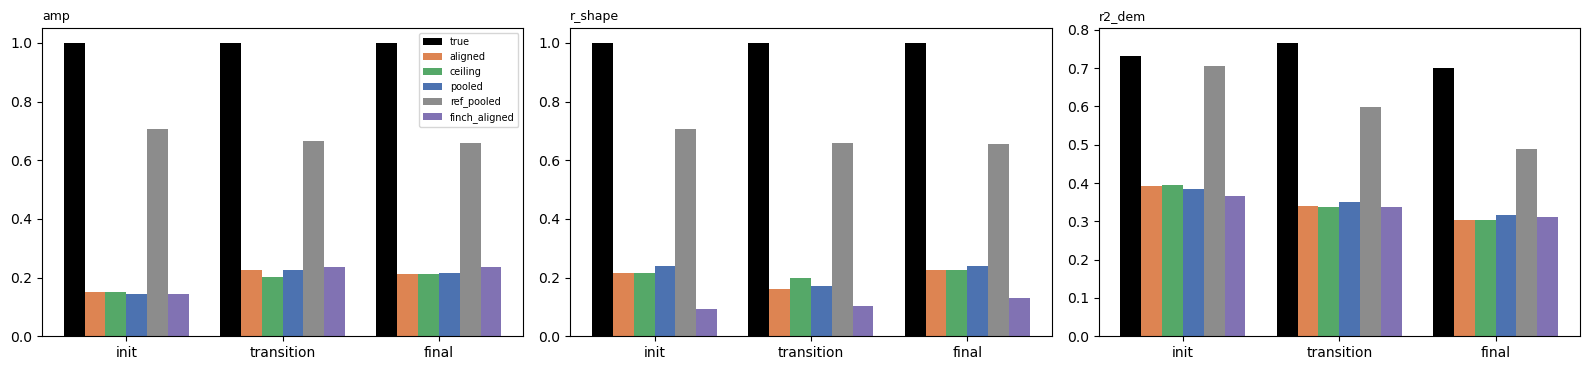

In [19]:
ALIGN168 = AL.Alignment(period_h=168, bin_h=None, block="phase")
OUT168 = AL.analyse(world, spec_f, ALIGN168, store=store, server=True, n_perm=99)
assert OUT168["checks"]["passed"].all()
cov = OUT168["coverage"]
display(cov.pivot_table(index="cycle", columns="phase", values="n_min")
           .reindex(columns=[p for p in RC.PERIODS if p in set(cov["phase"])]))
display(OUT168["summary"].round(3))
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
AL.plot_ladder_summary(ax, OUT168["summary"])
fig.tight_layout()
plt.show()

In [20]:
_ = AL.aligned_browser(OUT168["run"], OUT168["fid"], channels)

## 7. Invariance across blocks

For each client, class $g$ (weekday·hour), block $b$ (6 months within a phase) and channel $i$,
the block is compared with the **init** reference of the same class. The reference leaves out
the block's own months when the block lies inside init.

* `r_true` $=\mathrm{corr}_t(T_{b,g,i}, T_{ref,g,i})$ and `lvl_true`: does the *data* keep
  the class shape and level? This is the target, independent of any model.
* `d_lat` $= 1-\cos(z_{b,g}, z_{ref,g})$ and `e_lat` $=\lVert z_{b,g}-z_{ref,g}\rVert /
  \lVert z_{ref,g}\rVert$: does the *representation* move? Read these trained **against
  untrained**.
* `r_dec` $=\mathrm{corr}_t(\hat T_{b,g,i}, \hat T_{ref,g,i})$ on decoded mean latents, and
  `r_fid` $=\mathrm{corr}_t(\hat T_{b,g,i}, T_{b,g,i})$: does the decoded class move with the
  data, and does it look like it at all?

**Expected on this world:**
* pure channels of B, C and D stay at `r_true` ≈ 1;
* A departs through the transition;
* mixed channels that listen to A depart in proportion to their A weight.

With about 0.4 windows per class per month, a 6-month block holds about 2.6 windows per class,
so single cells are noisy and the summaries average over classes and channels.

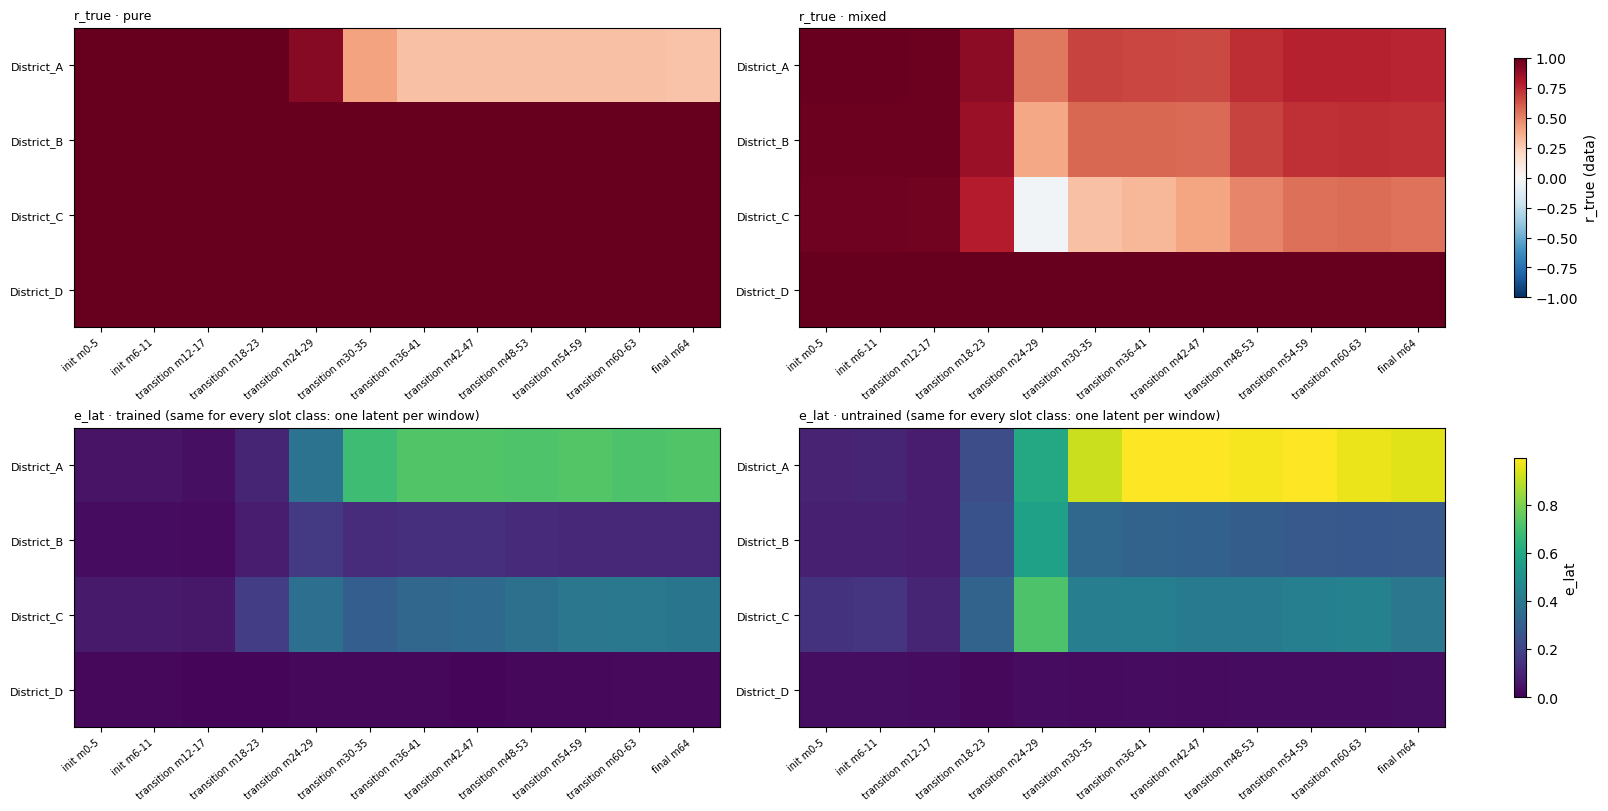

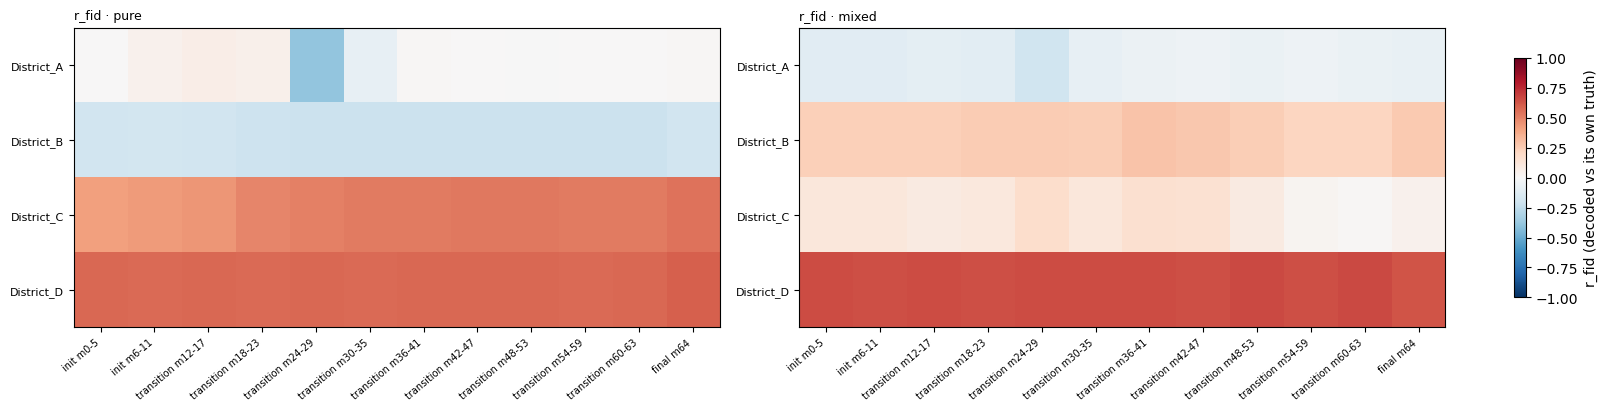

e_lat                    r_dec                    r_fid                   r_true                  
phase                  final   init transition  final   init transition  final   init transition  final   init transition
client     slot_class                                                                                                    
District_A mixed       0.723  0.054      0.537  0.400  0.992      0.540 -0.075 -0.112     -0.087  0.761  0.986      0.742
           pure        0.723  0.054      0.537 -0.260  0.986      0.141  0.011  0.026     -0.038  0.286  0.994      0.530
District_B mixed       0.109  0.034      0.114  0.935  0.993      0.925  0.264  0.239      0.246  0.729  0.982      0.677
           pure        0.109  0.034      0.114  0.989  0.998      0.987 -0.193 -0.188     -0.211  0.995  0.996      0.997
District_C mixed       0.386  0.071      0.304  0.534  0.973      0.643  0.041  0.115      0.104  0.547  0.970      0.481
           pure        0.386  0.071      0.304  0.945  0.989      0.899  0.544  0.416      0.506  0.995  0.994      0.996
District_D mixed       0.025  0.023      0.020  0.991  0.994      0.993  0.629  0.651      0.652  0.999  0.998      0.999
           pure        0.025  0.023      0.020  0.999  0.999      0.999  0.594  0.570      0.571  0.999  0.998      0.999

In [21]:
BLOCK = 6
INV = AL.invariance(world, run.wt, fw, model, channels, block=BLOCK)
INV_C = AL.invariance(world, ctrl.wt, fw, None, channels, block=BLOCK)
S_T, S_C = AL.invariance_summary(INV), AL.invariance_summary(INV_C)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), layout="constrained")
for j, cls in enumerate(("pure", "mixed")):
    im = AL.plot_invariance(axes[0, j], S_T, "r_true", cls, vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], shrink=0.8, label="r_true (data)")
vmax = float(np.nanpercentile(pd.concat([S_T["e_lat"], S_C["e_lat"]]), 98))
for j, (name, S) in enumerate((("trained", S_T), ("untrained", S_C))):
    im = AL.plot_invariance(axes[1, j], S, "e_lat", "pure", vmin=0, vmax=vmax,
                            cmap="viridis")
    axes[1, j].set_title(f"e_lat · {name} (same for every slot class: one latent "
                         "per window)", fontsize=9, loc="left")
fig.colorbar(im, ax=axes[1], shrink=0.8, label="e_lat")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4), layout="constrained")
for j, cls in enumerate(("pure", "mixed")):
    im = AL.plot_invariance(axes[j], S_T, "r_fid", cls, vmin=-1, vmax=1)
fig.colorbar(im, ax=axes, shrink=0.8, label="r_fid (decoded vs its own truth)")
plt.show()

display(S_T.pivot_table(index=["client", "slot_class"], columns="phase",
                        values=["r_true", "r_dec", "r_fid", "e_lat"])
           .round(3))

## 8. Latent diagnostics of the focus cell

These are the §8 tables of the first run for this cell: loss by round, the loss against flat
baselines, decoder levels, η² per snapshot round (round −1 = control), and the spread per
round.

In [22]:
for k in ("loss", "baselines"):
    display(san[k].round(4))
display(san["levels"].groupby(["client", "phase"])[["level_r", "level_ratio", "shape_amp"]]
          .mean().round(3))
display(san["eta"].pivot_table(index=["round", "stage"], columns="phase", values="lift",
                               sort=False).round(3))
display(san["spread"].round(4))

,round,loss,loss_mse,loss_proto,d_mse,aux_share
0,0,0.8376,0.3432,0.0000,NaN,0.5903
1,1,0.8974,0.3202,0.8308,-0.0671,0.6432
2,2,0.8736,0.2978,0.8181,-0.0698,0.6591
3,3,0.8563,0.2822,0.8073,-0.0523,0.6704
4,4,0.8457,0.2734,0.8056,-0.0312,0.6767
5,5,0.8414,0.2717,0.8022,-0.0064,0.6771
6,6,0.8426,0.2714,0.8026,-0.0012,0.6779
7,7,0.8319,0.2645,0.8002,-0.0253,0.6821
8,8,0.8309,0.2617,0.7944,-0.0107,0.6851
9,9,0.8279,0.2601,0.7924,-0.0060,0.6858


,client,n,loss_final,base_const,base_wmean,final_over_const,final_over_wmean
0,District_A,387,0.2859,0.4460,0.2646,0.6410,1.0806
1,District_B,387,0.3276,0.2947,0.2936,1.1118,1.1157
2,District_C,387,0.3118,0.3282,0.3142,0.9500,0.9923
3,District_D,387,0.2696,0.3300,0.3299,0.8170,0.8172


level_r  level_ratio  shape_amp
client     phase                                      
District_A final         0.780        3.245      0.273
           init          0.531        6.173      0.152
           transition    0.722        1.185      0.255
District_B final         0.493        2.873      0.188
           init          0.332        2.726      0.147
           transition    0.216        1.373      0.172
District_C final         0.634        2.101      0.236
           init          0.385        3.232      0.144
           transition    0.286        1.240      0.200
District_D final         0.980        4.343      0.143
           init          0.343        4.185      0.148
           transition    0.348        4.005      0.147

phase              all  final   init  transition
round     stage                                 
-1        pre    0.275  0.223  0.440       0.238
0         pre    0.258  0.161  0.444       0.217
          post   0.271  0.210  0.441       0.233
14        pre    0.256  0.162  0.421       0.219
          post   0.253  0.166  0.408       0.219
29        pre    0.303  0.213  0.460       0.268
          post   0.291  0.211  0.436       0.259
final_all post   0.297  0.211  0.440       0.266

,round,stage,n,norm,s_client,s_block,s_group,rel_block
0,-1,pre,1296,0.0821,0.0335,0.0277,0.0189,0.3377
1,0,post,1296,0.1038,0.0385,0.0308,0.0211,0.2965
2,0,pre,1296,0.1420,0.0616,0.0384,0.0274,0.2708
3,14,post,1296,0.4381,0.0894,0.0523,0.0366,0.1193
4,14,pre,1296,0.4433,0.0988,0.0544,0.0386,0.1226
5,29,post,1296,0.4652,0.1082,0.0705,0.0473,0.1515
6,29,pre,1296,0.4761,0.1209,0.0702,0.0469,0.1475
7,final_all,post,1548,0.4654,0.1085,0.0723,0.0502,0.1554


## What this leaves open

* **The decoder design.** The decoder receives the same latent vector at every step. In the
  harness, an undertrained decoder reproduces the first few steps and then settles to a
  constant, as an LSTM driven by constant input tends to do. If `long` still shows that shape
  in §5, the next axis is the architecture: feed the decoder a per-step time or phase encoding
  alongside $z$. That is an upstream `AER` change.
* **The drift window is short.** `final` is one month in this world, so the final side of §6
  and §7 rests on the transition blocks.
* **GPU equivalence.** `long·up pw0` and `long·lab pw0` are equivalent by construction and
  bit-identical on CPU (§2a). On GPU, compare them on the metrics.
* **Loss weights.** The loss-term weights are first guesses ($\lambda = 1$, $\gamma = 0.1$).
  Read §3 before sweeping them.